In [2]:
import pandas as pd
import numpy as np

# Load the provided file
df = pd.read_csv("C:/Users/panka/Downloads/telco_churn_with_all_feedback.csv")

In [3]:
# 1. Clean TotalCharges (convert to numeric and handle missing spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# 2. Convert Target to Binary (Churn: Yes/No -> 1/0)
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# 3. Drop columns that don't help the model (IDs and original prompts)
df = df.drop(['customerID', 'PromptInput'], axis=1)

print(f"Data Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Data Loaded: 7043 rows, 21 columns


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CustomerFeedback
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,I have been using the DSL internet service fro...
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,I have been a customer with this company for o...
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,I recently signed up for DSL internet service ...
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,I have been a loyal customer with this company...
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,I recently switched to this fiber optic intern...


In [5]:
from textblob import TextBlob

# 1. Extract Sentiment Polarity (-1 is negative, +1 is positive)
def get_sentiment(text):
    if pd.isna(text): return 0
    return TextBlob(str(text)).sentiment.polarity

print("Analyzing sentiment in feedback... (this may take a few seconds)")
df['Feedback_Sentiment'] = df['CustomerFeedback'].apply(get_sentiment)

# 2. Financial Feature: Percentage of total bill relative to tenure
df['Avg_Bill_Per_Month'] = df['TotalCharges'] / (df['tenure'] + 1)

# 3. Final Drop of original text column
df_final = df.drop(['CustomerFeedback'], axis=1)

df_final[['tenure', 'MonthlyCharges', 'Feedback_Sentiment', 'Churn']].head()

Analyzing sentiment in feedback... (this may take a few seconds)


,tenure,MonthlyCharges,Feedback_Sentiment,Churn
0,1,29.85,0.129545,0
1,34,56.95,0.170833,0
2,2,53.85,-0.228571,1
3,45,42.30,0.215801,0
4,2,70.70,0.030000,1


In [6]:
from sklearn.model_selection import train_test_split
import xgboost as xgb

# 1. Categorical Encoding (Convert 'gender', 'Contract', etc. to numbers)
# Using get_dummies is the quickest way for a notebook demonstration
df_encoded = pd.get_dummies(df_final, drop_first=True)

# 2. Split Data
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Initialize Advanced Gradient Boosting
model = xgb.XGBClassifier(
    n_estimators=150,
    learning_rate=0.03,
    max_depth=4,
    scale_pos_weight=2.5 # Handles class imbalance in churn
)

model.fit(X_train, y_train)
print("Model trained successfully with XGBoost.")

Model trained successfully with XGBoost.


Generating SHAP Explanations...


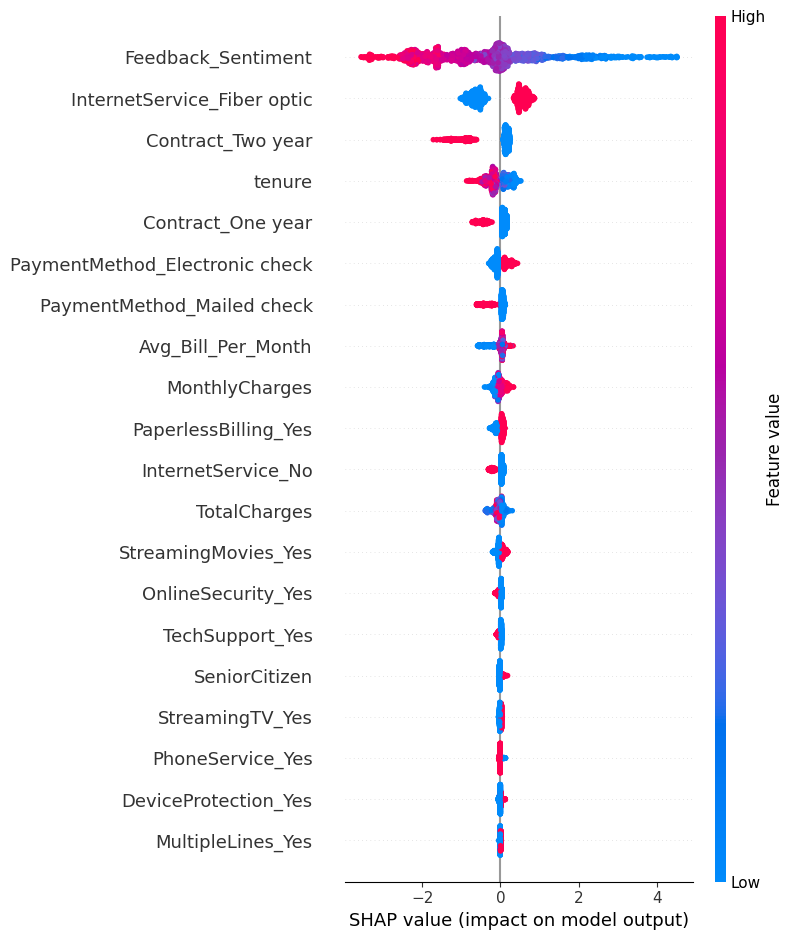

In [10]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize SHAP Explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 2. Summary Plot
# This will show how 'Feedback_Sentiment' and 'Contract' influence Churn
print("Generating SHAP Explanations...")
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

In [9]:
from sklearn.metrics import classification_report, roc_auc_score
import joblib
import os

# 1. Print Performance
y_pred = model.predict(X_test)
print("\n--- Model Performance Report ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.4f}")

# 2. Save Model for GitHub/Deployment
if not os.path.exists('exports'):
    os.makedirs('exports')

joblib.dump(model, 'exports/churn_model_v1.pkl')
joblib.dump(X.columns.tolist(), 'exports/feature_list.pkl')

print("\nModel and feature list saved in 'exports/' folder.")


--- Model Performance Report ---
              precision    recall  f1-score   support

           0       0.94      0.86      0.90      1035
           1       0.68      0.85      0.76       374

    accuracy                           0.86      1409
   macro avg       0.81      0.85      0.83      1409
weighted avg       0.87      0.86      0.86      1409

ROC-AUC Score: 0.9380

Model and feature list saved in 'exports/' folder.
